# Sports League Optimization

In [5]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from copy import deepcopy
from abc import ABC, abstractmethod
from copy import deepcopy

### Import Dataset

In [6]:
players_df = pd.read_csv(r"C:\Users\inesm\OneDrive\Documentos\GitHub\CIFO2025\data\players(in).csv")

### Initialize

In [7]:
POSITIONS = ["GK", "DEF", "MID", "FWD"]
TEAM_STRUCTURE = {"GK": 1, "DEF": 2, "MID": 2, "FWD": 2}
TEAM_SIZE = 7
N_TEAMS = 5
MAX_BUDGET = 750

### Class Solution

In [8]:
class Solution(ABC):
    def __init__(self, repr=None):
        if repr is None:
            repr = self.random_initial_representation()
        self.repr = repr

    def __repr__(self):
        return str(self.repr)

    @abstractmethod
    def fitness(self):
        pass

    @abstractmethod
    def random_initial_representation(self):
        pass

### Class Team (part of solution)

In [9]:
class Team:
    def __init__(self, players):
        self.players = players

    def is_valid(self):
        pos_count = {p: 0 for p in POSITIONS} #count players in each pos (start w/ 0)
        total_cost = 0
        for player in self.players:
            pos_count[player['Position']] += 1 #when a player is seen sums to the count
            total_cost += player['Salary (€M)'] #and sums their salary
        if any(pos_count[p] != TEAM_STRUCTURE[p] for p in POSITIONS):
            return False  #if any pos doesn't have exacly the right nº of players, its invalid
        if total_cost > MAX_BUDGET:
            return False  #if exceeds the budget, its false
        return True

    def average_skill(self):
        return np.mean([p['Skill'] for p in self.players]) #average skill of each team

### Class FootballSolution (individual of GA)

In [10]:
class FootballSolution(Solution):
    def __init__(self, repr=None, players_df=players_df):
        self.players_df = players_df
        super().__init__(repr=repr)

##por equanto,, por no is valid---
    def _validate_repr(self, repr):
        if not isinstance(repr, list):
            raise TypeError("Representation must be a list of Team objects")
        if len(repr) != N_TEAMS:
            raise ValueError("There must be exactly 5 teams")
        for team in repr:
            if not isinstance(team, Team):
                raise TypeError("Each element in the representation must be a Team")
            if not team.is_valid():
                raise ValueError("Each team must be valid (positions + budget)")

    
    def random_initial_representation(self):
        #initial available players
        all_players = self.players_df.to_dict('records')
        random.shuffle(all_players) #shuffle players

        # group players by position
        by_position = {pos: [] for pos in POSITIONS}
        for p in all_players:
            if p['Position'] in by_position:
                by_position[p['Position']].append(p)

        # shuffle each group of positions
        for pos_list in by_position.values():
            random.shuffle(pos_list)

        teams = []
        used_names = set()

        attempts = 0
        max_attempts = 100  # security for infinite loops

        while len(teams) < N_TEAMS and attempts < max_attempts:
            attempts += 1

            try:
                team_players = []

                for pos, count in TEAM_STRUCTURE.items():
                    # filters for non used players
                    available = [p for p in by_position[pos] if p['Name'] not in used_names]
                    if len(available) < count:
                        raise ValueError("Not enough players left for position:", pos)
                    team_players.extend(random.sample(available, count))  # picks the players

                team = Team(team_players)

                if team.is_valid():
                    teams.append(team)
                    used_names.update(p['Name'] for p in team_players)

            except Exception as e:
                continue  # fails, and trys again

        if len(teams) != N_TEAMS:
            print("[INFO] Could not create enough valid teams. Retrying full generation...")
            return self.random_initial_representation()

        return teams



    def fitness(self):
        valid_teams = [team for team in self.repr if team.is_valid()]
        if len(valid_teams) < 2:
            return 0
        skills = [team.average_skill() for team in valid_teams]
        return 1 / (1 + np.std(skills)) #WE MUST USE THIS FUNCTION BC IF NOT THERE WILL BE PLAYERS IN MORE THAN 1 TEAM
    
   

    #-----
    def deepcopy(self):
        return deepcopy(self)

Nota: Primeira versão do random ini. tinha estes problemas:<br>
--Estás a pegar 7 jogadores aleatórios e consecutivos, sem garantir que eles cobrem exatamente 1 GK, 2 DEF, 2 MID, 2 FWD.

--A maioria das vezes esses 7 jogadores não seguem o formato obrigatório.

--Isso leva a muitas tentativas falhadas até encontrares um grupo válido por acaso.

💡 É literalmente como procurar uma agulha no palheiro — só que a agulha são combinações raras e válidas no meio de muitas inválidas.

na nova versao:

--Selecionas diretamente o número certo de jogadores por posição;

--Evitas duplicados desde o início;

--Depois verificas se a equipa criada respeita o orçamento.

Isso significa:

--Zero tentativas com posições erradas ✅

--Menos tentativas rejeitadas por violar as regras

--Resulta num processo muito mais eficiente e direto

In [11]:
class FootballGA:
    def __init__(self, generations=50, pop_size=20, elite_size=2, selection_method="tournament", elitism=True, pc=0.9, pm=0.05, max_attempts=1000):
        self.generations = generations
        self.pop_size = pop_size
        self.elite_size = elite_size
        self.selection_method = selection_method
        self.elitism = elitism
        self.pc = pc
        self.pm = pm
        self.max_attempts = max_attempts
        self.population = []
        self.best_solution = None
        self.best_fitness = 0
        self.best_scores = []

    def initialize_population(self):
        print("Initializing population...")
        self.population = []
        attempts = 0
        max_attempts = 1000
        while len(self.population) < self.pop_size and attempts < max_attempts:
            try:
                sol = FootballSolution()
                if sol.fitness() > 0:
                    self.population.append(sol)
            except ValueError:
                pass
            attempts += 1

        if len(self.population) < self.pop_size:
            raise RuntimeError("Unable to initialize population with enough valid individuals.")


#------------------SELECTION-------------------------------------
    def tournament_selection(self, k=3):
        return max(random.sample(self.population, k), key=lambda s: s.fitness()).deepcopy()

    def fitness_proportionate_selection(self):
        fitness_values = [ind.fitness() for ind in self.population]
        total_fitness = sum(fitness_values)
        if total_fitness == 0:
            return random.choice(self.population).deepcopy()
        rand = random.uniform(0, total_fitness)
        cumulative = 0
        for ind, fit in zip(self.population, fitness_values):
            cumulative += fit
            if rand <= cumulative:
                return ind.deepcopy()

    def select_parent(self):
        return self.tournament_selection() if self.selection_method == "tournament" else self.fitness_proportionate_selection()


#-------------CROSSOVER---------------------    

    def team_swap_crossover(self, p1, p2):
        point = random.randint(1, N_TEAMS - 1)
        c1_repr = p1.repr[:point] + p2.repr[point:]
        c2_repr = p2.repr[:point] + p1.repr[point:]

        return FootballSolution(c1_repr), FootballSolution(c2_repr)

    def team_two_point_crossover(self, p1, p2):
        from copy import deepcopy

        # Selecionar dois pontos de corte distintos
        points = sorted(random.sample(range(1, N_TEAMS), 2))
        p1a, p1b = points

        # Fazer cópias das representações
        p1_repr = deepcopy(p1.repr)
        p2_repr = deepcopy(p2.repr)

        # Criar novos filhos com 2 pontos de corte
        c1_repr = p1_repr[:p1a] + p2_repr[p1a:p1b] + p1_repr[p1b:]
        c2_repr = p2_repr[:p1a] + p1_repr[p1a:p1b] + p2_repr[p1b:]

        # Construir soluções
        c1 = FootballSolution(repr=c1_repr)
        c2 = FootballSolution(repr=c2_repr)

        return c1, c2



#-------------MUTATIONS-------    
    def mutate_all(self, solution):
        if random.random() < self.pm:
            mutation = random.choice([
                self.mutate_swap_between_teams,
                self.mutate_global_position_permutation,
                self.mutate_random_position_swap
            ])
            solution = mutation(solution)
        return solution



    def mutate_swap_between_teams(self, solution):
        from copy import deepcopy
        new_repr = deepcopy(solution.repr)
        team_indices = random.sample(range(len(new_repr)), 2)
        t1, t2 = new_repr[team_indices[0]], new_repr[team_indices[1]]

        positions1 = {p['Position'] for p in t1.players}
        positions2 = {p['Position'] for p in t2.players}
        common_positions = list(positions1 & positions2)
        if not common_positions:
            return solution

        pos = random.choice(common_positions)
        p1_candidates = [i for i, p in enumerate(t1.players) if p['Position'] == pos]
        p2_candidates = [i for i, p in enumerate(t2.players) if p['Position'] == pos]

        if not p1_candidates or not p2_candidates:
            return solution

        i1 = random.choice(p1_candidates)
        i2 = random.choice(p2_candidates)

        t1.players[i1], t2.players[i2] = t2.players[i2], t1.players[i1]

        if t1.is_valid() and t2.is_valid():
            final_solution = solution.__class__(repr=new_repr)
            if self.is_unique(final_solution):
                return final_solution
        return solution
    
    def mutate_global_position_permutation(self, solution, position='DEF'):
        from copy import deepcopy
        new_repr = deepcopy(solution.repr)
        all_players = [p for team in new_repr for p in team.players if p['Position'] == position]
        if len(all_players) != 2 * len(new_repr):
            return solution

        random.shuffle(all_players)
        idx = 0
        for team in new_repr:
            count = 0
            for i, p in enumerate(team.players):
                if p['Position'] == position and count < 2:
                    team.players[i] = all_players[idx]
                    idx += 1
                    count += 1

        if all(team.is_valid() for team in new_repr):
            final_solution = solution.__class__(repr=new_repr)
            if self.is_unique(final_solution):
                return final_solution
        return solution


    def mutate_random_position_swap(self, solution):
        from copy import deepcopy
        new_repr = deepcopy(solution.repr)
        t1, t2 = random.sample(range(len(new_repr)), 2)

        players1 = new_repr[t1].players
        players2 = new_repr[t2].players

        possible_pairs = [(i, j) for i in range(len(players1)) for j in range(len(players2))
                        if players1[i]['Position'] == players2[j]['Position']]
        if not possible_pairs:
            return solution

        i1, i2 = random.choice(possible_pairs)
        players1[i1], players2[i2] = players2[i2], players1[i1]

        if new_repr[t1].is_valid() and new_repr[t2].is_valid():
            final_solution = solution.__class__(repr=new_repr)
            if self.is_unique(final_solution):
                return final_solution
        return solution
    
    
    def is_unique(self, solution):
        all_names = [p['Name'] for team in solution.repr for p in team.players]
        return len(all_names) == len(set(all_names))


#---------RUN FUNCTION--------------------------------------------------

    def runGA(self):
        print("Starting GA run...")
        self.initialize_population()

        for gen in range(self.generations):
            print(f"\n--- Generation {gen + 1} ---")
            fitnesses = [ind.fitness() for ind in self.population]
            self.best_scores.append(max(fitnesses))

            print(self.best_scores,":best score")
            
            best_gen = max(self.population, key=lambda s: s.fitness())
         
            if best_gen.fitness() > self.best_fitness:
                self.best_fitness = best_gen.fitness()
                self.best_solution = best_gen.deepcopy()

            new_population = []
            if self.elitism:
                elites = sorted(self.population, key=lambda s: -s.fitness())[:self.elite_size]
                print(f"Elitism: Copying {len(elites)} best individuals to new population")
                new_population.extend(elites)

            attempts = 0
            while len(new_population) < self.pop_size and attempts < self.max_attempts:
                print(f"New pop size: {len(new_population)} / {self.pop_size}")
                attempts += 1
                p1 = self.select_parent()
                p2 = self.select_parent()
                print("Selected parents")

                if random.random() < self.pc:
                    crossover_method = random.choice([
                        self.team_swap_crossover,
                        self.team_two_point_crossover
                    ])
                    c1, c2 = crossover_method(p1, p2)


                    # Aplica validações (ou fix_repr se quiseres)
                    if not self.is_unique(c1) or not self.is_unique(c2):
                        print("Filho descartado por repetição antes da mutação")
                        continue

                    if any(not team.is_valid() for team in c1.repr + c2.repr):
                        print("Filho inválido descartado")
                        continue

                    print("Applied crossover")
                else:
                    c1, c2 = p1.deepcopy(), p2.deepcopy()
                    print("Used replication")

                c1 = self.mutate_all(c1)
                c2 = self.mutate_all(c2)

                if not self.is_unique(c1) or not all(team.is_valid() for team in c1.repr):
                    print("Filho mutado c1 inválido")
                    continue
                if not self.is_unique(c2) or not all(team.is_valid() for team in c2.repr):
                    print("Filho mutado c2 inválido")
                    continue

                else:
                    print("Applied mutation")

                new_population.append(c1)
                if len(new_population) < self.pop_size:
                    new_population.append(c2)

            if attempts >= self.max_attempts:
                print(f"⚠️ Generation {gen+1}: broke after {self.max_attempts} attempts to create full population")

            self.population = new_population
            print(f"End of generation {gen + 1} | Best fitness so far: {self.best_fitness:.4f}")

    def plot(self):
        plt.plot(self.best_scores)
        plt.xlabel("Generation")
        plt.ylabel("Best Fitness")
        plt.title("GA Performance Over Generations")
        plt.grid(True)
        plt.show()

    def display_best_solution(self):
        if self.best_solution is None:
            print("\nNo valid solution found during the run.")
            return

        print("\nBest Score:", self.best_fitness)
        for i, team in enumerate(self.best_solution.repr):
            print(f"\nTeam {i + 1}:")
            for player in team.players:
                print(f"  {player['Name']} ({player['Position']}), Skill: {player['Skill']}, Cost: {player['Salary (€M)']}")

Starting GA run...
Initializing population...
[INFO] Could not create enough valid teams. Retrying full generation...

--- Generation 1 ---
[np.float64(0.7052365387324693)] :best score
Elitism: Copying 2 best individuals to new population
New pop size: 2 / 30
Selected parents
Used replication
Applied mutation
New pop size: 4 / 30
Selected parents
Filho descartado por repetição antes da mutação
New pop size: 4 / 30
Selected parents
Filho descartado por repetição antes da mutação
New pop size: 4 / 30
Selected parents
Filho descartado por repetição antes da mutação
New pop size: 4 / 30
Selected parents
Filho descartado por repetição antes da mutação
New pop size: 4 / 30
Selected parents
Filho descartado por repetição antes da mutação
New pop size: 4 / 30
Selected parents
Used replication
Applied mutation
New pop size: 6 / 30
Selected parents
Filho descartado por repetição antes da mutação
New pop size: 6 / 30
Selected parents
Filho descartado por repetição antes da mutação
New pop size: 6

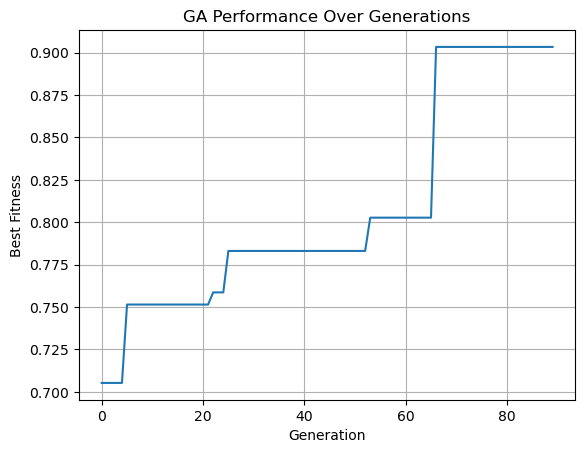


Best Score: 0.9034203067406401

Team 1:
  Jordan Smith (GK), Skill: 88, Cost: 100
  Maxwell Flores (DEF), Skill: 81, Cost: 72
  Mason Reed (DEF), Skill: 82, Cost: 75
  Nathan Wright (MID), Skill: 92, Cost: 120
  Gavin Richardson (MID), Skill: 87, Cost: 95
  Colton Gray (FWD), Skill: 91, Cost: 125
  Adrian Collins (FWD), Skill: 85, Cost: 90

Team 2:
  Chris Thompson (GK), Skill: 80, Cost: 80
  Lucas Bennett (DEF), Skill: 85, Cost: 90
  Daniel Foster (DEF), Skill: 90, Cost: 110
  Dylan Morgan (MID), Skill: 91, Cost: 115
  Austin Torres (MID), Skill: 82, Cost: 80
  Chase Murphy (FWD), Skill: 86, Cost: 95
  Xavier Bryant (FWD), Skill: 90, Cost: 120

Team 3:
  Ryan Mitchell (GK), Skill: 83, Cost: 85
  Caleb Fisher (DEF), Skill: 84, Cost: 85
  Ethan Howard (DEF), Skill: 80, Cost: 70
  Dominic Bell (MID), Skill: 86, Cost: 95
  Bentley Rivera (MID), Skill: 88, Cost: 100
  Landon Powell (FWD), Skill: 89, Cost: 110
  Sebastian Perry (FWD), Skill: 95, Cost: 150

Team 4:
  Alex Carter (GK), Skill

In [13]:
if __name__ == "__main__":
    ga = FootballGA(generations=90, pop_size=30, elite_size=2, selection_method="roulette", elitism=True, pc=0.9, pm=0.07)
    ga.runGA()
    ga.plot()
    ga.display_best_solution()
